In [1]:
import os
import os.path as op
import numpy as np
import nibabel as nib
import pandas as pd
from nilearn.maskers import NiftiMasker
from nilearn import datasets
from nilearn.image import threshold_img

## Define Dice Coefficient Function
The Dice coefficient measures the overlap between two binary masks, ranging from 0 (no overlap) to 1 (perfect overlap).

In [2]:
def dice_coefficient(mask1, mask2, brain_mask=None):
    """
    Calculate Dice similarity coefficient between two binary masks.
    
    Dice = 2 * |X ∩ Y| / (|X| + |Y|)
    
    Parameters:
    -----------
    mask1, mask2 : array-like
        Binary masks (1D or 3D arrays)
    brain_mask : array-like, optional
        Binary mask to restrict analysis to brain voxels
    
    Returns:
    --------
    dice : float
        Dice coefficient (0-1)
    """
    # Flatten arrays if needed
    mask1_flat = mask1.flatten()
    mask2_flat = mask2.flatten()
    
    # Apply brain mask if provided
    if brain_mask is not None:
        brain_mask_flat = brain_mask.flatten().astype(bool)
        mask1_flat = mask1_flat[brain_mask_flat]
        mask2_flat = mask2_flat[brain_mask_flat]
    
    # Calculate intersection and sizes
    intersection = np.sum(mask1_flat * mask2_flat)
    size1 = np.sum(mask1_flat)
    size2 = np.sum(mask2_flat)
    
    # Avoid division by zero
    if size1 + size2 == 0:
        return 0.0
    
    dice = (2.0 * intersection) / (size1 + size2)
    return dice

In [3]:
def weighted_dice_coefficient(map1, map2, brain_mask=None):
    """
    Calculate weighted Dice similarity coefficient between two continuous-valued maps.
    Weights voxels by their activation strength (absolute value).
    
    Weighted Dice = 2 * Σ(min(|X|, |Y|)) / (Σ|X| + Σ|Y|)
    
    Parameters:
    -----------
    map1, map2 : array-like
        Continuous-valued activation maps (1D or 3D arrays)
    brain_mask : array-like, optional
        Binary mask to restrict analysis to brain voxels
    
    Returns:
    --------
    weighted_dice : float
        Weighted Dice coefficient (0-1)
    """
    # Flatten arrays if needed
    map1_flat = map1.flatten()
    map2_flat = map2.flatten()
    
    # Apply brain mask if provided
    if brain_mask is not None:
        brain_mask_flat = brain_mask.flatten().astype(bool)
        map1_flat = map1_flat[brain_mask_flat]
        map2_flat = map2_flat[brain_mask_flat]
    
    # Use absolute values to handle negative activations
    map1_abs = np.abs(map1_flat)
    map2_abs = np.abs(map2_flat)
    
    # Calculate weighted intersection (minimum activation at each voxel)
    weighted_intersection = np.sum(np.minimum(map1_abs, map2_abs))
    
    # Calculate sum of activations
    sum1 = np.sum(map1_abs)
    sum2 = np.sum(map2_abs)
    
    # Avoid division by zero
    if sum1 + sum2 == 0:
        return 0.0
    
    weighted_dice = (2.0 * weighted_intersection) / (sum1 + sum2)
    return weighted_dice

In [4]:
def permutation_test_dice(map1, map2, dice_func, n_permutations=10000, seed=42):
    """
    Perform permutation test to assess statistical significance of Dice coefficient.
    Tests whether observed overlap is greater than expected by chance by randomly
    shuffling the spatial correspondence between the two maps.
    
    Parameters:
    -----------
    map1, map2 : array-like
        Maps to compare (binary or continuous, from masker.transform())
    dice_func : function
        Function to calculate Dice (dice_coefficient or weighted_dice_coefficient)
    n_permutations : int
        Number of permutations to perform
    seed : int
        Random seed for reproducibility
    
    Returns:
    --------
    p_value : float
        One-tailed p-value (proportion of permutations with Dice >= observed)
    null_distribution : array
        Dice coefficients from permuted data
    observed_dice : float
        Observed Dice coefficient
    """
    rng = np.random.RandomState(seed)
    
    # Ensure arrays are 1D
    if map1.ndim > 1:
        map1 = map1.flatten()
    if map2.ndim > 1:
        map2 = map2.flatten()
    
    # Calculate observed Dice
    observed_dice = dice_func(map1, map2)
    
    # Initialize null distribution
    null_dice = np.zeros(n_permutations)
    
    # Perform permutations
    for i in range(n_permutations):
        # Randomly shuffle map2 to break spatial correspondence
        map2_permuted = rng.permutation(map2)
        # Calculate Dice for permuted data
        null_dice[i] = dice_func(map1, map2_permuted)
    
    # Calculate one-tailed p-value
    # p-value = proportion of null distribution >= observed
    # Small p-value means observed is significantly greater than chance
    p_value = np.sum(null_dice >= observed_dice) / n_permutations
    
    return p_value, null_dice, observed_dice

## Setup Directories and Masker

In [5]:
data_dir = "./dset"

# Setup masker
mask_img = datasets.load_mni152_brain_mask(resolution=1)
masker = NiftiMasker(mask_img=mask_img)
masker = masker.fit()

# Load MNI152 template to use as brain mask
template_img = datasets.load_mni152_template(resolution=1)
template_data = template_img.get_fdata()
brain_mask = (template_data != 0).astype(int)

print(f"Brain mask shape: {brain_mask.shape}")
print(f"Brain voxels: {np.sum(brain_mask)}")

Brain mask shape: (197, 233, 189)
Brain voxels: 1886539


## Define File Paths

In [6]:
# Group directories
group_drawn_dir = op.join(data_dir, "group-drawn/habenula")
group_avg_dir = op.join(data_dir, "group-avg/habenula")

# File paths for group average (1-sample) maps
drawn_1s_fn = op.join(group_drawn_dir, "averaged", "sub-group_task-rest_desc-1SampletTest_thresh.nii.gz")
avg_1s_fn = op.join(group_avg_dir, "averaged", "sub-group_task-rest_desc-1SampletTest_thresh.nii.gz")

# File paths for group comparison (2-sample) maps
drawn_2s_fn = op.join(group_drawn_dir, "difference", "sub-group_task-rest_desc-2SampletTest_thresh.nii.gz")
avg_2s_fn = op.join(group_avg_dir, "difference", "sub-group_task-rest_desc-2SampletTest_thresh.nii.gz")

print("File paths defined:")
print(f"Drawn 1-sample: {drawn_1s_fn}")
print(f"Avg 1-sample: {avg_1s_fn}")
print(f"Drawn 2-sample: {drawn_2s_fn}")
print(f"Avg 2-sample: {avg_2s_fn}")

File paths defined:
Drawn 1-sample: ./dset/group-drawn/habenula/averaged/sub-group_task-rest_desc-1SampletTest_thresh.nii.gz
Avg 1-sample: ./dset/group-avg/habenula/averaged/sub-group_task-rest_desc-1SampletTest_thresh.nii.gz
Drawn 2-sample: ./dset/group-drawn/habenula/difference/sub-group_task-rest_desc-2SampletTest_thresh.nii.gz
Avg 2-sample: ./dset/group-avg/habenula/difference/sub-group_task-rest_desc-2SampletTest_thresh.nii.gz


## Calculate Dice Coefficients for Group Average Maps (1-Sample)

In [7]:
# Check if files exist
if not op.exists(drawn_1s_fn):
    print(f"ERROR: File not found: {drawn_1s_fn}")
elif not op.exists(avg_1s_fn):
    print(f"ERROR: File not found: {avg_1s_fn}")
else:
    # Load thresholded maps
    drawn_1s_img = nib.load(drawn_1s_fn)
    avg_1s_img = nib.load(avg_1s_fn)
    
    # Convert to arrays (masker already applies brain mask)
    drawn_1s_arr = masker.transform(drawn_1s_img)
    avg_1s_arr = masker.transform(avg_1s_img)
    
    # Create binary masks (any non-zero value = 1)
    drawn_1s_binary = (drawn_1s_arr != 0).astype(int)
    avg_1s_binary = (avg_1s_arr != 0).astype(int)
    
    # Calculate binary Dice coefficient (masker already restricts to brain voxels)
    dice_1s = dice_coefficient(drawn_1s_binary, avg_1s_binary)
    
    # Calculate weighted Dice coefficient (uses activation strength)
    weighted_dice_1s = weighted_dice_coefficient(drawn_1s_arr, avg_1s_arr)
    
    # Perform permutation tests
    print("\n=== Group Average (1-Sample) ===")
    
    # Check if binary maps are identical
    if np.array_equal(drawn_1s_binary.flatten(), avg_1s_binary.flatten()):
        print("Binary maps are identical - permutation test not applicable")
        p_binary_1s = np.nan
        null_binary_1s = np.array([dice_1s])
        obs_binary_1s = dice_1s
    else:
        print("Running binary permutation test (10,000 permutations)...")
        p_binary_1s, null_binary_1s, obs_binary_1s = permutation_test_dice(
            drawn_1s_binary, avg_1s_binary, dice_coefficient, n_permutations=10000
        )
    
    print("Running weighted permutation test (10,000 permutations)...")
    p_weighted_1s, null_weighted_1s, obs_weighted_1s = permutation_test_dice(
        drawn_1s_arr, avg_1s_arr, weighted_dice_coefficient, n_permutations=10000
    )
    
    if np.isnan(p_binary_1s):
        print(f"Binary Dice Coefficient: {dice_1s:.4f} (identical maps)")
    else:
        if p_binary_1s == 0.0:
            print(f"Binary Dice Coefficient: {dice_1s:.4f} (p < 0.0001)")
        else:
            print(f"Binary Dice Coefficient: {dice_1s:.4f} (p = {p_binary_1s:.6f})")
    
    if p_weighted_1s == 0.0:
        print(f"Weighted Dice Coefficient: {weighted_dice_1s:.4f} (p < 0.0001)")
    else:
        print(f"Weighted Dice Coefficient: {weighted_dice_1s:.4f} (p = {p_weighted_1s:.6f})")
    
    print(f"Hand-drawn map voxels: {np.sum(drawn_1s_binary)}")
    print(f"Average habenula map voxels: {np.sum(avg_1s_binary)}")
    print(f"Overlapping voxels: {np.sum(drawn_1s_binary * avg_1s_binary)}")

/Users/chloehampson/Desktop/habenula-abide-rsfc/.venv/lib/python3.9/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(
/Users/chloehampson/Desktop/habenula-abide-rsfc/.venv/lib/python3.9/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(
/Users/chloehampson/Desktop/habenula-abide-rsfc/.venv/lib/python3.9/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You mig


=== Group Average (1-Sample) ===
Binary maps are identical - permutation test not applicable
Running weighted permutation test (10,000 permutations)...
Binary Dice Coefficient: 1.0000 (identical maps)
Weighted Dice Coefficient: 0.7498 (p < 0.0001)
Hand-drawn map voxels: 1882989
Average habenula map voxels: 1882989
Overlapping voxels: 1882989
Binary Dice Coefficient: 1.0000 (identical maps)
Weighted Dice Coefficient: 0.7498 (p < 0.0001)
Hand-drawn map voxels: 1882989
Average habenula map voxels: 1882989
Overlapping voxels: 1882989


In [8]:
# Check if files exist
if not op.exists(drawn_2s_fn):
    print(f"ERROR: File not found: {drawn_2s_fn}")
elif not op.exists(avg_2s_fn):
    print(f"ERROR: File not found: {avg_2s_fn}")
else:
    # Load thresholded maps
    drawn_2s_img = nib.load(drawn_2s_fn)
    avg_2s_img = nib.load(avg_2s_fn)
    
    # Convert to arrays (masker already applies brain mask)
    drawn_2s_arr = masker.transform(drawn_2s_img)
    avg_2s_arr = masker.transform(avg_2s_img)
    
    # Create binary masks (any non-zero value = 1)
    drawn_2s_binary = (drawn_2s_arr != 0).astype(int)
    avg_2s_binary = (avg_2s_arr != 0).astype(int)
    
    # Calculate binary Dice coefficient (masker already restricts to brain voxels)
    dice_2s = dice_coefficient(drawn_2s_binary, avg_2s_binary)
    
    # Calculate weighted Dice coefficient (uses activation strength)
    weighted_dice_2s = weighted_dice_coefficient(drawn_2s_arr, avg_2s_arr)
    
    # Perform permutation tests
    print("\n=== Group Comparison (2-Sample) ===")
    print("Running permutation tests (10,000 permutations)...")
    p_binary_2s, null_binary_2s, obs_binary_2s = permutation_test_dice(
        drawn_2s_binary, avg_2s_binary, dice_coefficient, n_permutations=10000
    )
    p_weighted_2s, null_weighted_2s, obs_weighted_2s = permutation_test_dice(
        drawn_2s_arr, avg_2s_arr, weighted_dice_coefficient, n_permutations=10000
    )
    
    if p_binary_2s == 0.0:
        print(f"Binary Dice Coefficient: {dice_2s:.4f} (p < 0.0001)")
    else:
        print(f"Binary Dice Coefficient: {dice_2s:.4f} (p = {p_binary_2s:.6f})")
    
    if p_weighted_2s == 0.0:
        print(f"Weighted Dice Coefficient: {weighted_dice_2s:.4f} (p < 0.0001)")
    else:
        print(f"Weighted Dice Coefficient: {weighted_dice_2s:.4f} (p = {p_weighted_2s:.6f})")
    
    print(f"Hand-drawn map voxels: {np.sum(drawn_2s_binary)}")
    print(f"Average habenula map voxels: {np.sum(avg_2s_binary)}")
    print(f"Overlapping voxels: {np.sum(drawn_2s_binary * avg_2s_binary)}")

/Users/chloehampson/Desktop/habenula-abide-rsfc/.venv/lib/python3.9/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(
/Users/chloehampson/Desktop/habenula-abide-rsfc/.venv/lib/python3.9/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(
/Users/chloehampson/Desktop/habenula-abide-rsfc/.venv/lib/python3.9/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You mig


=== Group Comparison (2-Sample) ===
Running permutation tests (10,000 permutations)...
Binary Dice Coefficient: 0.5144 (p < 0.0001)
Weighted Dice Coefficient: 0.3361 (p < 0.0001)
Hand-drawn map voxels: 927424
Average habenula map voxels: 943232
Overlapping voxels: 481146
Binary Dice Coefficient: 0.5144 (p < 0.0001)
Weighted Dice Coefficient: 0.3361 (p < 0.0001)
Hand-drawn map voxels: 927424
Average habenula map voxels: 943232
Overlapping voxels: 481146


## Visualize Null Distributions

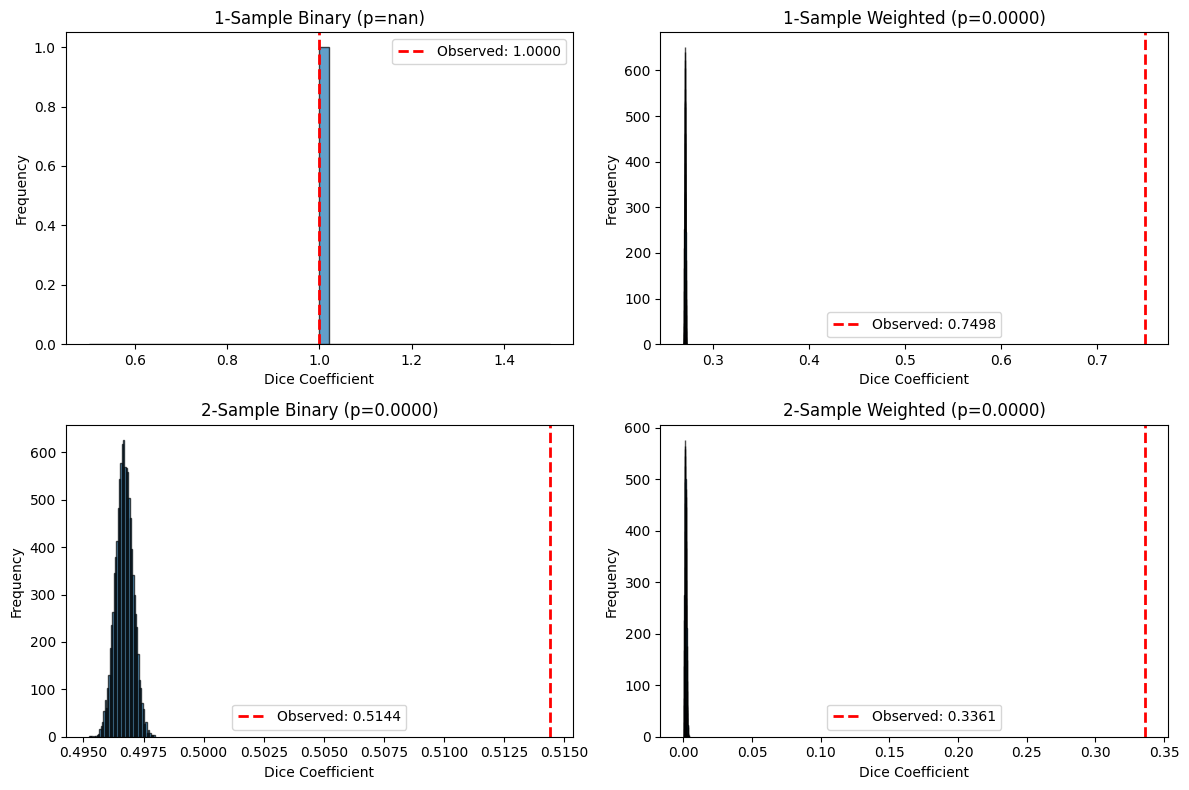


Null distribution statistics:
1-Sample Binary: mean=1.0000, observed=1.0000
1-Sample Weighted: mean=0.2709, observed=0.7498
2-Sample Binary: mean=0.4967, observed=0.5144
2-Sample Weighted: mean=0.0016, observed=0.3361


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1-sample binary
axes[0, 0].hist(null_binary_1s, bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].axvline(obs_binary_1s, color='red', linestyle='--', linewidth=2, label=f'Observed: {obs_binary_1s:.4f}')
axes[0, 0].set_xlabel('Dice Coefficient')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'1-Sample Binary (p={p_binary_1s:.4f})')
axes[0, 0].legend()

# Plot 1-sample weighted
axes[0, 1].hist(null_weighted_1s, bins=50, alpha=0.7, edgecolor='black')
axes[0, 1].axvline(obs_weighted_1s, color='red', linestyle='--', linewidth=2, label=f'Observed: {obs_weighted_1s:.4f}')
axes[0, 1].set_xlabel('Dice Coefficient')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'1-Sample Weighted (p={p_weighted_1s:.4f})')
axes[0, 1].legend()

# Plot 2-sample binary
axes[1, 0].hist(null_binary_2s, bins=50, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(obs_binary_2s, color='red', linestyle='--', linewidth=2, label=f'Observed: {obs_binary_2s:.4f}')
axes[1, 0].set_xlabel('Dice Coefficient')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title(f'2-Sample Binary (p={p_binary_2s:.4f})')
axes[1, 0].legend()

# Plot 2-sample weighted
axes[1, 1].hist(null_weighted_2s, bins=50, alpha=0.7, edgecolor='black')
axes[1, 1].axvline(obs_weighted_2s, color='red', linestyle='--', linewidth=2, label=f'Observed: {obs_weighted_2s:.4f}')
axes[1, 1].set_xlabel('Dice Coefficient')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title(f'2-Sample Weighted (p={p_weighted_2s:.4f})')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(op.join(data_dir, 'dice_permutation_distributions.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\nNull distribution statistics:")
print(f"1-Sample Binary: mean={np.mean(null_binary_1s):.4f}, observed={obs_binary_1s:.4f}")
print(f"1-Sample Weighted: mean={np.mean(null_weighted_1s):.4f}, observed={obs_weighted_1s:.4f}")
print(f"2-Sample Binary: mean={np.mean(null_binary_2s):.4f}, observed={obs_binary_2s:.4f}")
print(f"2-Sample Weighted: mean={np.mean(null_weighted_2s):.4f}, observed={obs_weighted_2s:.4f}")

In [10]:
# Create summary dataframe with proper p-value formatting
def format_pvalue(p):
    if np.isnan(p):
        return "N/A (identical)"
    elif p == 0.0:
        return "< 0.0001"
    else:
        return f"{p:.6f}"

summary_data = {
    "Analysis Type": ["Group Average (1-Sample)", "Group Comparison (2-Sample)"],
    "Binary Dice": [f"{dice_1s:.4f}", f"{dice_2s:.4f}"],
    "Binary p-value": [format_pvalue(p_binary_1s), format_pvalue(p_binary_2s)],
    "Weighted Dice": [f"{weighted_dice_1s:.4f}", f"{weighted_dice_2s:.4f}"],
    "Weighted p-value": [format_pvalue(p_weighted_1s), format_pvalue(p_weighted_2s)],
    "Hand-Drawn Voxels": [int(np.sum(drawn_1s_binary)), int(np.sum(drawn_2s_binary))],
    "Avg Habenula Voxels": [int(np.sum(avg_1s_binary)), int(np.sum(avg_2s_binary))],
    "Overlapping Voxels": [
        int(np.sum(drawn_1s_binary * avg_1s_binary)),
        int(np.sum(drawn_2s_binary * avg_2s_binary))
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n=== Dice Similarity Summary ===")
print(summary_df.to_string(index=False))
print("\nInterpretation:")
print("- Binary Dice = 1.0 means the thresholded maps are identical in spatial extent")
print("- Weighted Dice < 1.0 means activation magnitudes differ even when locations overlap")
print("- p < 0.05 indicates the observed similarity is significantly greater than chance")
print("- p < 0.0001 means none of the 10,000 permutations exceeded the observed value")


=== Dice Similarity Summary ===
              Analysis Type Binary Dice  Binary p-value Weighted Dice Weighted p-value  Hand-Drawn Voxels  Avg Habenula Voxels  Overlapping Voxels
   Group Average (1-Sample)      1.0000 N/A (identical)        0.7498         < 0.0001            1882989              1882989             1882989
Group Comparison (2-Sample)      0.5144        < 0.0001        0.3361         < 0.0001             927424               943232              481146

Interpretation:
- Binary Dice = 1.0 means the thresholded maps are identical in spatial extent
- Weighted Dice < 1.0 means activation magnitudes differ even when locations overlap
- p < 0.05 indicates the observed similarity is significantly greater than chance
- p < 0.0001 means none of the 10,000 permutations exceeded the observed value


## Save Results

In [11]:
# Save summary to CSV
output_fn = op.join(data_dir, "dice_similarity_results.csv")
summary_df.to_csv(output_fn, index=False)
print(f"\nResults saved to: {output_fn}")


Results saved to: ./dset/dice_similarity_results.csv


In [12]:
# Check if observed Dice is far outside the null distribution
import numpy as np

# For 1-sample (Group Average)
def check_robustness(observed, null, label):
    mean_null = np.mean(null)
    std_null = np.std(null)
    z_score = (observed - mean_null) / std_null if std_null > 0 else np.nan
    print(f"{label}:")
    print(f"  Observed Dice: {observed:.4f}")
    print(f"  Null mean:     {mean_null:.4f}")
    print(f"  Null std:      {std_null:.4f}")
    print(f"  Z-score:       {z_score:.2f}")
    if z_score > 3:
        print("  Result is robust: observed value is far outside the null distribution (z > 3)")
    elif z_score > 2:
        print("  Result is likely robust (z > 2)")
    else:
        print("  Result is not far outside the null (z <= 2)")
    print()

check_robustness(obs_binary_1s, null_binary_1s, "1-Sample Binary Dice")
check_robustness(obs_weighted_1s, null_weighted_1s, "1-Sample Weighted Dice")
check_robustness(obs_binary_2s, null_binary_2s, "2-Sample Binary Dice")
check_robustness(obs_weighted_2s, null_weighted_2s, "2-Sample Weighted Dice")

1-Sample Binary Dice:
  Observed Dice: 1.0000
  Null mean:     1.0000
  Null std:      0.0000
  Z-score:       nan
  Result is not far outside the null (z <= 2)

1-Sample Weighted Dice:
  Observed Dice: 0.7498
  Null mean:     0.2709
  Null std:      0.0004
  Z-score:       1250.26
  Result is robust: observed value is far outside the null distribution (z > 3)

2-Sample Binary Dice:
  Observed Dice: 0.5144
  Null mean:     0.4967
  Null std:      0.0004
  Z-score:       48.72
  Result is robust: observed value is far outside the null distribution (z > 3)

2-Sample Weighted Dice:
  Observed Dice: 0.3361
  Null mean:     0.0016
  Null std:      0.0006
  Z-score:       603.67
  Result is robust: observed value is far outside the null distribution (z > 3)

